# 08 — Dual Axis (`twinx`)
**When to use:** Two metrics on the same chart that have very different scales.
Example: sessions (thousands) and CVR (%) on the same time axis.

**Warning:** Dual axis can mislead if misused. Only use it when the two metrics are genuinely related and you want to show their co-movement.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/raw/funnel_data.csv', parse_dates=['date'])

daily = df.groupby('date').agg(
    sessions=('visita_landing', 'sum'),
    activations=('activacion_tarjeta', 'sum')
).reset_index()
daily['cvr'] = daily['activations'] / daily['sessions'] * 100
daily['roll_cvr'] = daily['cvr'].rolling(7, center=True).mean()

print(daily.head())

        date  sessions  activations       cvr  roll_cvr
0 2024-01-01      3097           69  2.227963       NaN
1 2024-01-02      2851           64  2.244826       NaN
2 2024-01-03      2978           65  2.182673       NaN
3 2024-01-04      2845           61  2.144112  2.184776
4 2024-01-05      2914           64  2.196294  2.185102


## How `twinx` works
`ax2 = ax1.twinx()` creates a second Axes that shares the same x-axis but has its own y-axis on the right side.

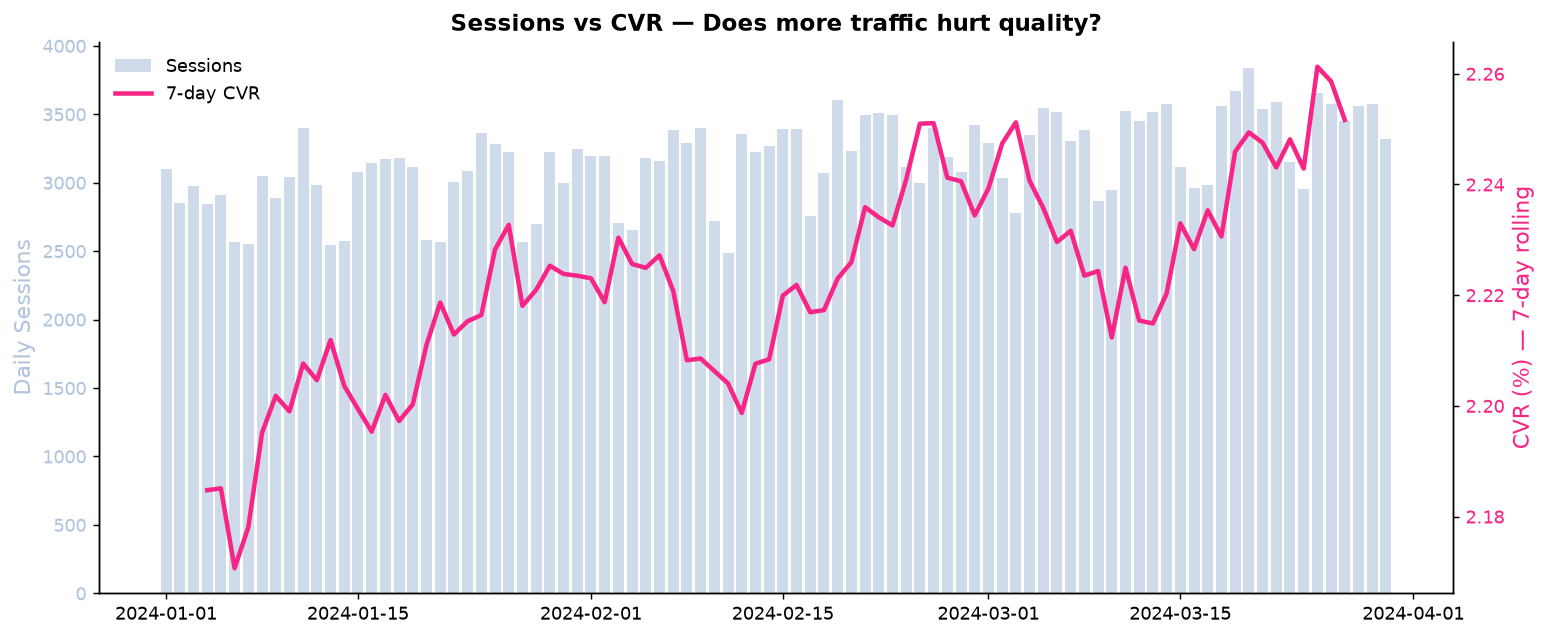

In [2]:
fig, ax1 = plt.subplots(figsize=(12, 5), dpi=130)

# --- Left axis: sessions (bars) ---
color_sessions = '#b0c4de'
ax1.bar(daily['date'], daily['sessions'],
        color=color_sessions, alpha=0.6, label='Sessions')
ax1.set_ylabel('Daily Sessions', color=color_sessions, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_sessions)
ax1.spines['top'].set_visible(False)

# --- Right axis: CVR (line) ---
# twinx() shares the x-axis and adds a new y-axis on the right
ax2 = ax1.twinx()
color_cvr = '#f72585'
ax2.plot(daily['date'], daily['roll_cvr'],
         color=color_cvr, linewidth=2.5, label='7-day CVR')
ax2.set_ylabel('CVR (%) — 7-day rolling', color=color_cvr, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_cvr)
ax2.spines['top'].set_visible(False)

# Title on ax1 (the base axes)
ax1.set_title('Sessions vs CVR — Does more traffic hurt quality?',
              fontsize=13, fontweight='bold')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, loc='upper left')

plt.tight_layout()
plt.savefig('data/08_dual_axis.png', dpi=150, bbox_inches='tight')
plt.show()

## Paid spend vs activations
A more realistic use case: does increasing paid spend generate proportionally more activations?

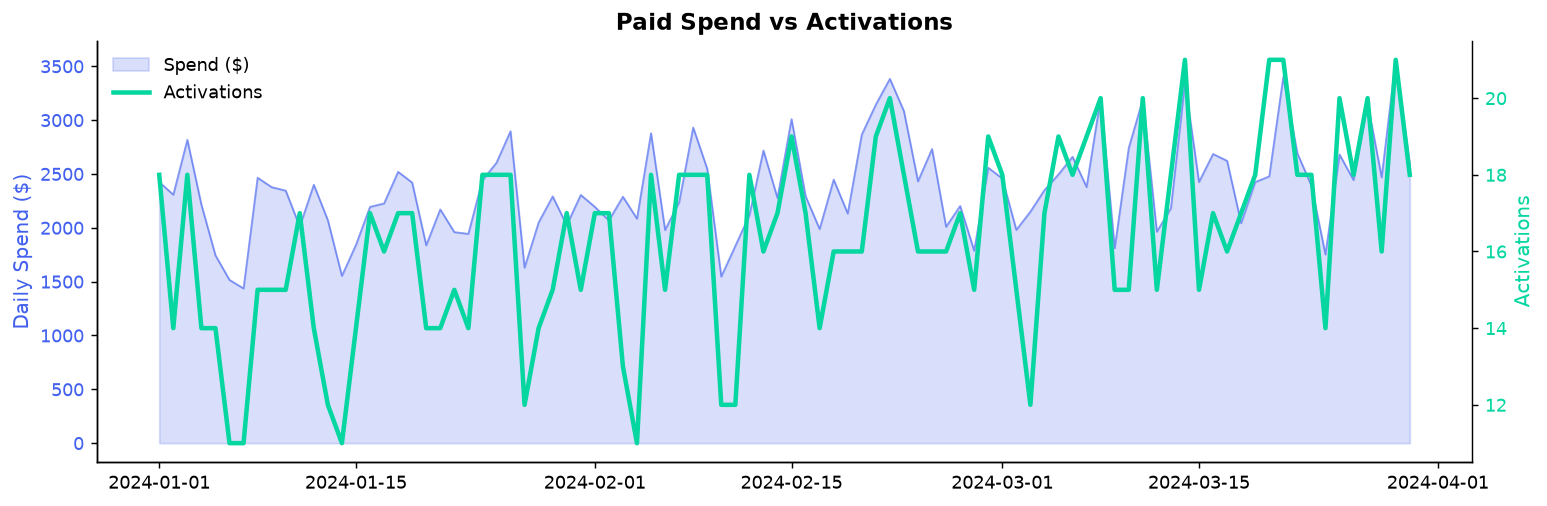

In [3]:
# Simulate paid spend (not in our dataset, but realistic)
np.random.seed(42)
paid_daily = df[df['channel'] == 'paid'].groupby('date').agg(
    sessions=('visita_landing', 'sum'),
    activations=('activacion_tarjeta', 'sum')
).reset_index()

# Simulate spend correlated with sessions
paid_daily['spend'] = paid_daily['sessions'] * np.random.uniform(0.8, 1.2, len(paid_daily)) * 2.5

fig, ax1 = plt.subplots(figsize=(12, 4), dpi=130)

# Spend as area
ax1.fill_between(paid_daily['date'], paid_daily['spend'],
                 color='#4361ee', alpha=0.2, label='Spend ($)')
ax1.plot(paid_daily['date'], paid_daily['spend'],
         color='#4361ee', linewidth=1, alpha=0.6)
ax1.set_ylabel('Daily Spend ($)', color='#4361ee', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#4361ee')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Activations as line on right axis
ax2 = ax1.twinx()
ax2.plot(paid_daily['date'], paid_daily['activations'],
         color='#06d6a0', linewidth=2.5, label='Activations')
ax2.set_ylabel('Activations', color='#06d6a0', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#06d6a0')
ax2.spines['top'].set_visible(False)

ax1.set_title('Paid Spend vs Activations', fontsize=13, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, loc='upper left')

plt.tight_layout()
plt.show()

# Key rule: color-code each y-axis label to match its line/bar.
# The reader should never have to guess which axis belongs to which metric.

## Summary
| | |
|---|---|
| **Create** | `ax2 = ax1.twinx()` |
| **Color y-labels** | `ax.set_ylabel(..., color=color)` + `ax.tick_params(labelcolor=color)` |
| **Combined legend** | `ax1.get_legend_handles_labels()` + `ax2.get_legend_handles_labels()` |
| **When to use** | Two related metrics with different scales on the same time axis |
| **When NOT to use** | More than 2 y-axes, or unrelated metrics |

**Next:** `09_small_multiples.ipynb`